In [1]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar

from numpy.fft import fft, fftfreq
# https://numpy.org/doc/stable/reference/routines.fft.html
# fft calcula la transformada
# fftfreq calcula las (posibles) frecuencias involucradas

plt.rcParams["figure.figsize"] = (10,5) #tamaño de los gráficos: ancho x alto

In [2]:
#cada término de la serie de Fourier
def simple_compleja(a,f,t):
  y = a*np.exp(1j*2*np.pi*f*t)
  return y

# calcula el polinomio trigonométrico que aproxima a la función periódica.
# dft es la transformada discreta de Fourier de la muestra de la función periódica.
def aprox_fourier(freqs, dft, t):
  cantidad = len(freqs)
  dft_normalizada = dft/cantidad
  y = 0
  for i in range(0,cantidad,1):
    y = y + simple_compleja(dft_normalizada[i], freqs[i], t)
  return y

In [3]:
# cambiar por cualquiera que se quiera aproximar
def f_periodica(t):
  y = t**2
  return y

/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 0, 'Tiempo')

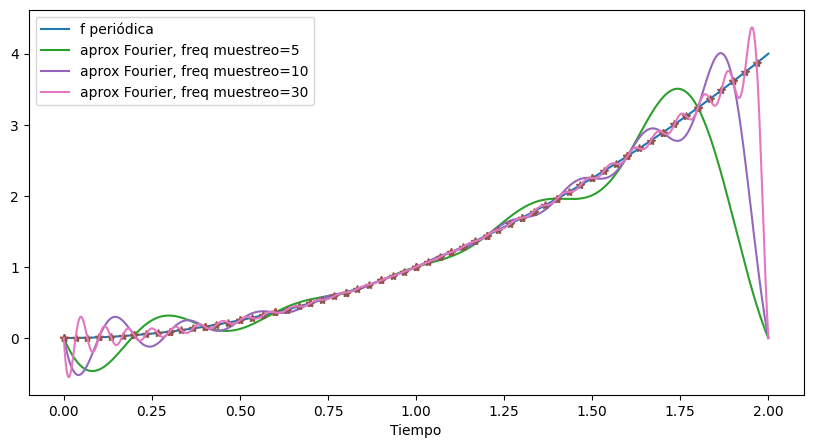

In [4]:
# empezar en cero porque sino se rompe. De todos modos al ser f periódica, podemos pensar que la trasladamos y listo.
b = 2 #el intervalo de periodicidad siempre es [0,b]
vals_t_graficar = np.linspace(0, b, 1000)

# grafico a la f periódica real
vals_f_periodica_graficar = f_periodica(vals_t_graficar)
plt.plot(vals_t_graficar, vals_f_periodica_graficar, label="f periódica")

frecuencias_de_muestreo = [5,10,30]

for freq_muestreo in frecuencias_de_muestreo:
  paso_temporal = 1/freq_muestreo

  # calculo la muestra de la f periódica
  vals_t_muestra = np.arange(0, b, paso_temporal)
  vals_f_muestra = f_periodica(vals_t_muestra)

  # grafico a la muestra
  plt.plot(vals_t_muestra, vals_f_muestra, "*")

  # calculo la TDF de la muestra
  vals_f_fourier = fft(vals_f_muestra)

  # calculo las potenciales frecuencias involucradas
  cantidad_muestras = len(vals_t_muestra)
  frecuencias = fftfreq(cantidad_muestras, d=paso_temporal)

  # calculo y grafico la aproximación por Fourier
  vals_aprox_fourier_graficar = aprox_fourier(frecuencias, vals_f_fourier, vals_t_graficar)
  plt.plot(vals_t_graficar, vals_aprox_fourier_graficar, label="aprox Fourier, freq muestreo={}".format(freq_muestreo))

plt.legend()
plt.xlabel('Tiempo')